# 04 — Warm-Start Fine-Tune
Fine-tunes Qwen2.5-Coder on all knowledge pairs extracted by notebooks 03 and 05
to give the model a solid understanding of ARO syntax before the RL explore loop.

Uses LoRA with conservative settings (8 layers, LR 1e-5, max-seq-length 2048,
grad-checkpoint) to avoid gradient instability on long sequences.
Training progress is shown as a live loss graph and progress bar.

**Run after:** notebook 03 (and optionally notebook 05 for book Q&A pairs)

**Input:**  `../data/02_knowledge/knowledge_pairs.jsonl`  (from notebooks 03 + 05)
            `../data/02_knowledge/knowledge.json`          (for system prompt)
**Output:** `../data/adapters/warm_start/`                 (LoRA adapter)
            `../data/02_knowledge/knowledge.json`          (updated with adapter path)

In [1]:
import sys, importlib
from pathlib import Path
_cfg_dir = Path('.').resolve()
if _cfg_dir not in [Path(p) for p in sys.path]:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *
print(f'Config loaded | model={MODEL_ID}')
print(f'ARO root:  {ARO_ROOT}')
print(f'Pairs:     {PAIRS_FILE}')
print(f'Adapters:  {ADAPTER_DIR}')

import gc, json, re, random, subprocess, sys
from pathlib import Path
from collections import Counter

with open(DATA_DIR / 'knowledge.json') as f:
    kb = json.load(f)

print(f'Knowledge pairs: {PAIRS_FILE}')
print(f'Adapter output:  {ADAPTER_DIR}')

/Library/Python/3.9/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/kris/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Knowledge pairs: /Users/kris/Projects/ARO-App/Train/script/../data/02_knowledge/knowledge_pairs.jsonl
Adapter output:  /Users/kris/Projects/ARO-App/Train/script/../data/adapters


In [2]:
# Load all knowledge pairs produced by notebooks 03 and 05
all_pairs = []
with open(PAIRS_FILE) as f:
    for line in f:
        if line.strip():
            try:
                all_pairs.append(json.loads(line))
            except Exception:
                pass

sources = Counter(p['source'].split(':')[0] for p in all_pairs)
scores  = Counter(round(p.get('score', 1.0), 1) for p in all_pairs)

print(f'Total pairs: {len(all_pairs)}')
print('\nBy source:')
for src, n in sorted(sources.items(), key=lambda x: -x[1]):
    print(f'  {src:30s}: {n}')
print('\nBy score:')
for score, n in sorted(scores.items(), key=lambda x: -x[0]):
    print(f'  {score}: {n}')

Total pairs: 859

By source:
  example                       : 482
  proposal                      : 273
  aro_by_example                : 54
  book                          : 50

By score:
  1.0: 859


In [3]:
# Build system prompt from action metadata (same prompt used in notebooks 03 and 06)
action_lines = []
for a in kb['actions']:
    if a['verbs']:
        v = '/'.join(a['verbs'][:3])
        p = ', '.join(a['prepositions'][:4])
        action_lines.append(f'- {v}  (role: {a["role"]}, prepositions: {p})')

SYSTEM_PROMPT = f"""You are an expert ARO language programmer.
ARO (Action Result Object) is a DSL for business logic as natural-language statements.

SYNTAX:
  (FeatureSetName: BusinessActivity) {{
      Verb [the] <result[:qualifier]> preposition [the] <object[:qualifier]>.
  }}

KEY RULES:
- Articles (a/an/the) are optional
- String concatenation: ++ (NOT +)
- Variable names: hyphenated lowercase e.g. <user-id>, <order-total>
- Forbidden variable name prefixes: is-, with-, empty-
- Exactly ONE Application-Start per application
- openapi.yaml required for HTTP server; operationId must match feature set name
- Long-running apps: Keepalive the <application> for the <events>.
- Return statuses: <OK: status>, <Created: status>, <NotFound: status>
- HTTP path params: Extract the <id> from the <pathParameters: id>.
- Request body:     Extract the <data> from the <request: body>.

AVAILABLE ACTIONS:
{chr(10).join(action_lines[:40])}

Always wrap ARO code in ```aro ... ``` fences."""

print(f'System prompt: {len(SYSTEM_PROMPT)} chars')

System prompt: 1939 chars


## Warm-Start Fine-Tune

Fine-tune Qwen2.5-Coder on all extracted pairs so it understands ARO syntax
before notebook 06 starts generating synthetic data.

Uses 8 LoRA layers (same as the RL loop in notebook 06) with a conservative
learning rate of 1e-5 to prevent gradient instability on long sequences.
Sequences are truncated to 2048 tokens and `--grad-checkpoint` reduces peak memory.

The adapter is saved to `../data/adapters/warm_start/` and notebook 06
will automatically load it as the starting point for RL fine-tuning rounds.

Tokenizer loaded: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Pairs after expansion: 988  (kept 794, split into 194, dropped 5)
SFT data: 890 train, 98 valid
Warm-start: 300 steps, 8 LoRA layers


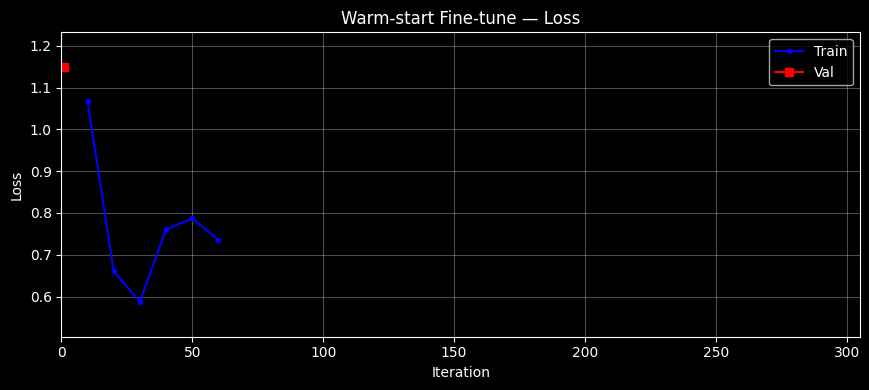

Fine-tuning:   0%|          | 0/300 [00:00<?, ?iter/s]

Running: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m mlx_lm lora --model mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit --data /Users/kris/Projects/ARO-App/Train/script/../data/warm_start_sft --train --num-layers 8 --iters 300 --batch-size 2 --learning-rate 1e-5 --adapter-path /Users/kris/Projects/ARO-App/Train/script/../data/adapters/warm_start --mask-prompt --max-seq-length 2048 --grad-checkpoint --save-every 60 --val-batches 5


Fine-tuning:   0%|          | 0/300 [00:00<?, ?iter/s]

  /Library/Python/3.9/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
    warnings.warn(


Fine-tuning:   0%|          | 0/300 [00:01<?, ?iter/s]

...

  iter   60/300  │  train_loss 0.7350  │  lr 1.00e-05  │  0.095 it/s  │  46 tok/s  │  46355 tokens  │  mem 25.426 GB  │  ETA 42m06s


Fine-tuning:  20%|██        | 60/300 [16:21<51:58, 12.99s/iter, loss=0.735, it/s=0.095, mem_GB=25.426, ETA=42m06s]

  Traceback (most recent call last):
    File "/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "/Users/kris/Library/Python/3.9/lib/python/site-packages/mlx_lm/__main__.py", line 30, in <module>
      submodule.main()
    File "/Users/kris/Library/Python/3.9/lib/python/site-packages/mlx_lm/lora.py", line 362, in main
      run(types.SimpleNamespace(**args))
    File "/Users/kris/Library/Python/3.9/lib/python/site-packages/mlx_lm/lora.py", line 334, in run
      train_model(args, model, train_set, valid_set, training_callback)
    File "/Users/kris/Library/Python/3.9/lib/python/site-packages/mlx_lm/lora.py", line 288, in train_model
      train(
    Fil

Fine-tuning:  20%|██        | 60/300 [16:22<1:05:31, 16.38s/iter, loss=0.735, it/s=0.095, mem_GB=25.426, ETA=42m06s]



Fine-tune exited with code 1


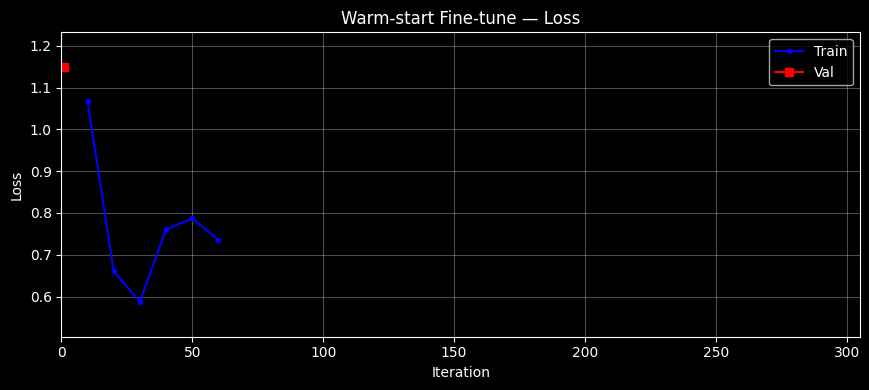

In [4]:
import sys, importlib
from pathlib import Path
_cfg_dir = Path('.').resolve()
if _cfg_dir not in [Path(p) for p in sys.path]:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *
print(f'Config loaded | model={MODEL_ID}')
print(f'ARO root:  {ARO_ROOT}')
print(f'Pairs:     {PAIRS_FILE}')
print(f'Adapters:  {ADAPTER_DIR}')

import matplotlib.pyplot as plt
from IPython import display as ipydisplay
try:
    import ipywidgets
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

SFT_DIR      = GLOBAL_OUT_DIR / '../data/warm_start_sft'
SFT_DIR.mkdir(parents=True, exist_ok=True)

# ── Load tokenizer for exact token counts (no model weights needed) ──────────
from transformers import AutoTokenizer
_tok = AutoTokenizer.from_pretrained(MODEL_ID)
print(f'Tokenizer loaded: {MODEL_ID}')

MAX_TOKENS = 2000   # leave 48-token margin below the 2048 hard limit

def _count_tokens(instruction, output):
    """Exact token count for the full chat message including system prompt."""
    text = _tok.apply_chat_template([
        {'role': 'system',    'content': SYSTEM_PROMPT},
        {'role': 'user',      'content': instruction},
        {'role': 'assistant', 'content': output},
    ], tokenize=False, add_generation_prompt=False)
    return len(_tok.encode(text))

# ── Pre-process: split long pairs so nothing gets truncated ──────────────────
# Truncation mid-ARO-block teaches the model to produce incomplete code.
# Strategy:
#   1. Fits within MAX_TOKENS → keep as-is
#   2. Multi-file pair (## filename sections) → split into one pair per file
#   3. Still too long after splitting → drop (and report)

_file_section_re = re.compile(r'(##\s+\S+.*?)(?=\n##\s+\S+|\Z)', re.DOTALL)

def _split_by_file(output):
    sections = _file_section_re.findall(output)
    return sections if len(sections) > 1 else []

def expand_pair(p):
    instruction, output = p['instruction'], p['output']

    if _count_tokens(instruction, output) <= MAX_TOKENS:
        return [(instruction, output)]

    sections = _split_by_file(output)
    if sections:
        result = [(instruction, s) for s in sections
                  if _count_tokens(instruction, s) <= MAX_TOKENS]
        if result:
            return result

    return []   # drop

expanded, stats = [], {'kept': 0, 'split': 0, 'dropped': 0}
for p in all_pairs:
    parts = expand_pair(p)
    if not parts:
        stats['dropped'] += 1
    elif len(parts) == 1 and parts[0][1] == p['output']:
        stats['kept'] += 1
        expanded.append({**p, 'instruction': parts[0][0], 'output': parts[0][1]})
    else:
        stats['split'] += len(parts)
        for instruction, output in parts:
            expanded.append({'instruction': instruction, 'output': output,
                             'source': p.get('source', ''), 'score': p.get('score', 1.0)})

print(f'Pairs after expansion: {len(expanded)}  '
      f'(kept {stats["kept"]}, split into {stats["split"]}, dropped {stats["dropped"]})')

# ── Shuffle and split ────────────────────────────────────────────────────────
random.shuffle(expanded)
split = max(1, int(len(expanded) * 0.1))

def pair_to_chat(p):
    return {'messages': [
        {'role': 'system',    'content': SYSTEM_PROMPT},
        {'role': 'user',      'content': p['instruction']},
        {'role': 'assistant', 'content': p['output']},
    ]}

(SFT_DIR / 'valid.jsonl').write_text(
    '\n'.join(json.dumps(pair_to_chat(p)) for p in expanded[:split]))
(SFT_DIR / 'train.jsonl').write_text(
    '\n'.join(json.dumps(pair_to_chat(p)) for p in expanded[split:]))

n_train = len(expanded) - split
iters   = max(100, min(300, n_train * 3))

print(f'SFT data: {n_train} train, {split} valid')
print(f'Warm-start: {iters} steps, 8 LoRA layers')

cmd = [
    sys.executable, '-m', 'mlx_lm', 'lora',
    '--model',          MODEL_ID,
    '--data',           str(SFT_DIR),
    '--train',
    '--num-layers',     '8',
    '--iters',          str(iters),
    '--batch-size',     '2',
    '--learning-rate',  '1e-5',
    '--adapter-path',   str(WARM_ADAPTER),
    '--mask-prompt',
    '--max-seq-length', '2048',
    '--grad-checkpoint',
    '--save-every',     str(max(50, iters // 5)),
    '--val-batches',    '5',
]

# ── Live loss graph ──────────────────────────────────────────────────────────
train_iters, train_losses = [], []
val_iters,   val_losses   = [], []

fig, ax = plt.subplots(figsize=(9, 4))
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Warm-start Fine-tune — Loss')
ax.grid(True, alpha=0.3)
train_line, = ax.plot([], [], 'b-o', ms=3, lw=1.5, label='Train')
val_line,   = ax.plot([], [], 'r-s', ms=6, lw=1.5, label='Val')
ax.legend()
plt.tight_layout()

_fig_handle = ipydisplay.display(fig, display_id=True)

def _refresh_plot():
    if train_losses:
        train_line.set_data(train_iters, train_losses)
    if val_losses:
        val_line.set_data(val_iters, val_losses)
    all_y = train_losses + val_losses
    if all_y:
        lo, hi = min(all_y), max(all_y)
        pad = max(0.05, (hi - lo) * 0.15)
        ax.set_ylim(lo - pad, hi + pad)
    all_x = train_iters + val_iters
    if all_x:
        ax.set_xlim(0, max(iters, max(all_x)) + 5)
    fig.canvas.draw()
    _fig_handle.update(fig)

# ── Regexes for mlx-lm log lines ────────────────────────────────────────────
_train_re = re.compile(
    r'Iter\s+(\d+):\s+Train loss\s+([\d.]+)'
    r'(?:.*?Learning Rate\s+([\d.e+-]+))?'
    r'(?:.*?It/sec\s+([\d.]+))?'
    r'(?:.*?Tokens/sec\s+([\d.]+))?'
    r'(?:.*?Trained Tokens\s+([\d,]+))?'
    r'(?:.*?Peak mem\s+([\d.]+)\s*GB)?'
)
_val_re   = re.compile(r'Iter\s+(\d+):\s+Val loss\s+([\d.]+)(?:.*?Val took\s+([\d.]+)s)?')
_saved_re = re.compile(r'Adapter saved', re.IGNORECASE)

# ── Progress bar + subprocess ────────────────────────────────────────────────
pbar      = tqdm(total=iters, desc='Fine-tuning', unit='iter', dynamic_ncols=True)
last_iter = 0

print('Running:', ' '.join(cmd))
proc = subprocess.Popen(
    cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1,
)
try:
    for raw_line in proc.stdout:
        line = raw_line.rstrip()

        m_train = _train_re.search(line)
        m_val   = _val_re.search(line)

        if m_train:
            it, loss    = int(m_train.group(1)), float(m_train.group(2))
            lr, it_sec  = m_train.group(3), m_train.group(4)
            tok_sec     = m_train.group(5)
            trained_tok = m_train.group(6)
            peak_mem    = m_train.group(7)

            train_iters.append(it)
            train_losses.append(loss)
            pbar.update(it - last_iter)
            last_iter = it

            eta_str = ''
            if it_sec:
                eta_s = (iters - it) / float(it_sec)
                h, r  = divmod(int(eta_s), 3600)
                m_, s = divmod(r, 60)
                eta_str = f'{h}h{m_:02d}m' if h else f'{m_}m{s:02d}s'

            postfix = {'loss': f'{loss:.3f}'}
            if it_sec:   postfix['it/s']   = it_sec
            if peak_mem: postfix['mem_GB'] = peak_mem
            if eta_str:  postfix['ETA']    = eta_str
            pbar.set_postfix(postfix)

            parts = [f'iter {it:>4}/{iters}', f'train_loss {loss:.4f}']
            if lr:          parts.append(f'lr {float(lr):.2e}')
            if it_sec:      parts.append(f'{float(it_sec):.3f} it/s')
            if tok_sec:     parts.append(f'{float(tok_sec):.0f} tok/s')
            if trained_tok: parts.append(f'{trained_tok.replace(",","")} tokens')
            if peak_mem:    parts.append(f'mem {peak_mem} GB')
            if eta_str:     parts.append(f'ETA {eta_str}')
            tqdm.write('  ' + '  │  '.join(parts))
            _refresh_plot()

        elif m_val:
            it, loss    = int(m_val.group(1)), float(m_val.group(2))
            val_took    = m_val.group(3)

            val_iters.append(it)
            val_losses.append(loss)
            pbar.set_postfix({'loss': f'{train_losses[-1]:.3f}' if train_losses else '?',
                              'val':  f'{loss:.3f}'})
            took_str = f'  ({val_took}s)' if val_took else ''
            tqdm.write(f'  ── val ──  iter {it:>4}/{iters}  val_loss {loss:.4f}{took_str}')
            _refresh_plot()

        elif _saved_re.search(line):
            tqdm.write(f'  ✓ {line}')
        elif line.strip():
            tqdm.write(f'  {line}')

finally:
    proc.wait()
    pbar.close()

_refresh_plot()

if proc.returncode == 0:
    print(f'\nWarm-start adapter saved to: {WARM_ADAPTER}')
else:
    print(f'\nFine-tune exited with code {proc.returncode}')

In [5]:
# Update knowledge.json so notebook 06 finds the warm-start adapter automatically
kb['warm_start_adapter']    = str(WARM_ADAPTER)
kb['knowledge_pairs_file']  = str(PAIRS_FILE)
kb['knowledge_pairs_count'] = len(all_pairs)

with open(DATA_DIR / 'knowledge.json', 'w') as f:
    json.dump(kb, f, indent=2)

print('Updated knowledge.json')
print()
print('Next steps:')
print(f'  Adapter path: {WARM_ADAPTER}')
print(f'  Run notebook 06 — it will auto-load this adapter and run the RL explore loop')

Updated knowledge.json

Next steps:
  Adapter path: /Users/kris/Projects/ARO-App/Train/script/../data/adapters/warm_start
  Run notebook 06 — it will auto-load this adapter and run the RL explore loop
